<a href="https://colab.research.google.com/github/axelmartinezportillo/industrial-software-data-analysis/blob/main/Notebook/Caso_Practico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
# 1. Carga de datos
df = pd.read_csv('https://raw.githubusercontent.com/axelmartinezportillo/industrial-software-data-analysis/refs/heads/main/data/Prestige_modificado.csv', sep=';')

In [ ]:
# 2. Revisión de Estructura y Calidad
print(f"Registros: {df.shape[0]} | Columnas: {df.shape[1]}")
print(f"Nulos: {df.isnull().sum().sum()} | Duplicados: {df.duplicated().sum()}")

Registros: 102 | Columnas: 7
Nulos: 0 | Duplicados: 0


In [ ]:
# Definimos las variables numéricas
variables_analisis = ['education', 'income', 'women', 'prestige']

print("--- Revisión de valores atípicos (Media +/- 2 Desviaciones) ---")

for col in variables_analisis:
    media = df[col].mean()
    desviacion = df[col].std()

    # Calculamos los límites
    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    # Identificamos los registros fuera de los límites
    atipicos = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

    print(f"Variable: {col}")
    print(f"  > Media: {round(media, 2)} | Desviación: {round(desviacion, 2)}")
    print(f"  > Límites: [{round(limite_inferior, 2)} a {round(limite_superior, 2)}]")
    print(f"  > Cantidad de atípicos: {len(atipicos)}")
    print("-" * 50)

--- Revisión de valores atípicos (Media +/- 2 Desviaciones) ---
Variable: education
  > Media: 10.74 | Desviación: 2.73
  > Límites: [5.28 a 16.19]
  > Cantidad de atípicos: 0
--------------------------------------------------
Variable: income
  > Media: 6797.9 | Desviación: 4245.92
  > Límites: [-1693.94 a 15289.75]
  > Cantidad de atípicos: 4
--------------------------------------------------
Variable: women
  > Media: 28.98 | Desviación: 31.72
  > Límites: [-34.47 a 92.43]
  > Cantidad de atípicos: 6
--------------------------------------------------
Variable: prestige
  > Media: 46.83 | Desviación: 17.2
  > Límites: [12.42 a 81.24]
  > Cantidad de atípicos: 3
--------------------------------------------------


--- Correlaciones con respecto al Prestigio (Prestige) ---
prestige     1.000
education    0.850
income       0.715
women       -0.118
type_num    -0.465
census      -0.635
Name: prestige, dtype: float64


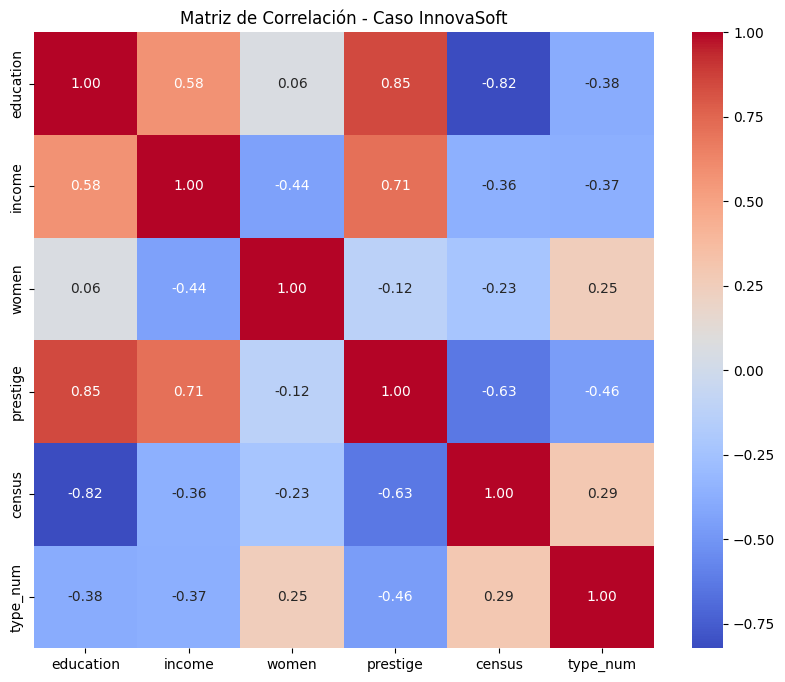

In [ ]:
# 1. Calcular la matriz de correlación de las variables numéricas
variables_numericas = df.select_dtypes(include=['int64', 'float64'])
matriz_correlacion = variables_numericas.corr()

# 2. Ordenar las correlaciones tomando como referencia la variable 'prestige'
print("--- Correlaciones con respecto al Prestigio (Prestige) ---")
print(matriz_correlacion['prestige'].sort_values(ascending=False).round(3))

# 3. Visualización con Mapa de Calor
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Caso InnovaSoft")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Selección de variables para clusterizar
columnas_cluster = ['education', 'income', 'women', 'prestige']
X = df[columnas_cluster].copy()

# 2. Escalado de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Modelo con 4 Clústeres
modelo_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_4'] = modelo_k4.fit_predict(X_scaled)

# 4. Modelo con 5 Clústeres
modelo_k5 = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_5'] = modelo_k5.fit_predict(X_scaled)

# 5. Mostrar los Centroides (Promedios por grupo) para comparar
print("--- Centroides Modelo 4 Clústeres ---")
display(df.groupby('Cluster_4')[columnas_cluster].mean().round(2))

print("\n--- Centroides Modelo 5 Clústeres ---")
display(df.groupby('Cluster_5')[columnas_cluster].mean().round(2))

--- Centroides Modelo 4 Clústeres ---


,education,income,women,prestige
Cluster_4,,,,
0,8.52,5599.02,9.77,35.17
1,14.69,15746.83,6.00,74.23
2,10.05,3395.95,76.66,37.73
3,13.08,7482.85,30.27,60.73



--- Centroides Modelo 5 Clústeres ---


,education,income,women,prestige
Cluster_5,,,,
0,9.93,3337.95,75.73,36.44
1,10.70,7661.44,9.28,49.22
2,14.73,15338.00,7.44,73.85
3,14.17,6723.85,53.79,65.96
4,7.94,4629.50,11.39,30.90


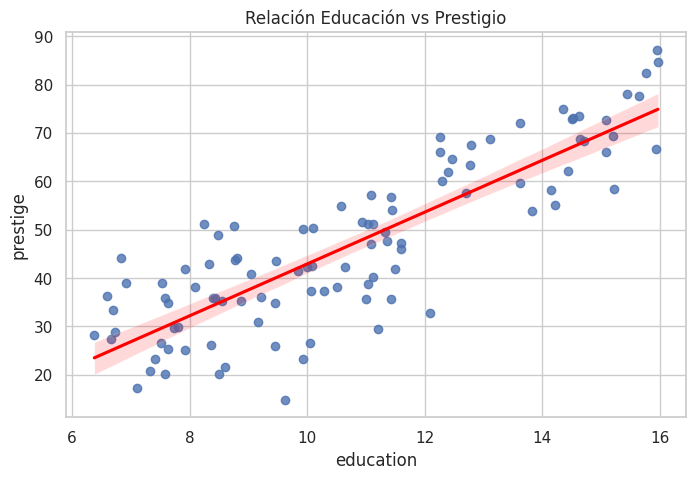

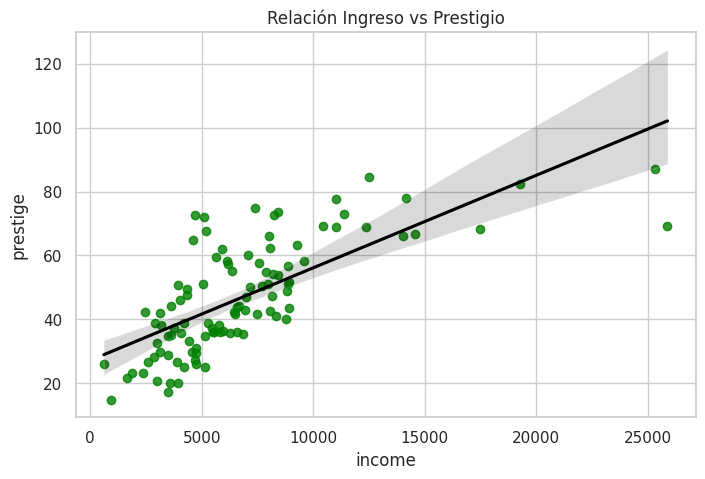

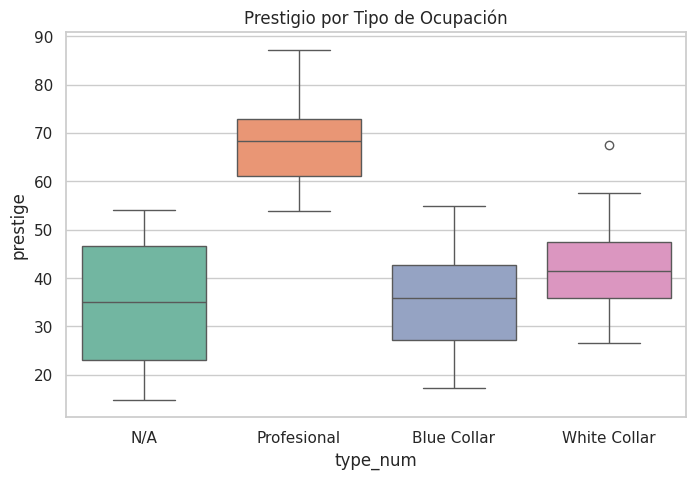

In [ ]:
# --- ACTIVIDAD 3: VISUALIZACIÓN DE RESULTADOS (VERSIÓN ACTUALIZADA) ---
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Gráfica: Educación vs Prestigio
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='education', y='prestige', line_kws={"color": "red"})
plt.title('Relación Educación vs Prestigio')
plt.show()
plt.close()

# 2. Gráfica: Ingreso vs Prestigio
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='income', y='prestige', color='green', line_kws={"color": "black"})
plt.title('Relación Ingreso vs Prestigio')
plt.show()
plt.close()

# 3. Gráfica: Comparación por Tipo
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='type_num', y='prestige', hue='type_num', palette='Set2', legend=False)
plt.xticks([0, 1, 2, 3], ['N/A', 'Profesional', 'Blue Collar', 'White Collar'])
plt.title('Prestigio por Tipo de Ocupación')
plt.show()